In [24]:
import copy, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Libraries loaded")

✓ Libraries loaded


In [25]:
df = pd.read_csv('../data/Housing.csv')
print(f"Shape of the dataset: {df.shape}")
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())
print(f"\nMissing values:")
print(df.isnull().sum())


Shape of the dataset: (545, 13)
First 5 rows of the dataset:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Dataset info:
<class 'pandas.DataFram

In [26]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
X_train = df[features].values.astype(float)
y_train = df['price'].values.astype(float)
X_features = features

m, n = X_train.shape
print(f"X_train shape : {X_train.shape}  → {m} examples, {n} features")
print(f"y_train shape : {y_train.shape}")
print(f"\nFeature ranges (raw):")
for i, feat in enumerate(X_features):
    print(f"  {feat:12s}: {X_train[:,i].min():.0f}  to  {X_train[:,i].max():.0f}")
print(f"\nPrice range: ${y_train.min():,.0f}  to  ${y_train.max():,.0f}")

X_train shape : (545, 5)  → 545 examples, 5 features
y_train shape : (545,)

Feature ranges (raw):
  area        : 1650  to  16200
  bedrooms    : 1  to  6
  bathrooms   : 1  to  4
  stories     : 1  to  4
  parking     : 0  to  3

Price range: $1,750,000  to  $13,300,000


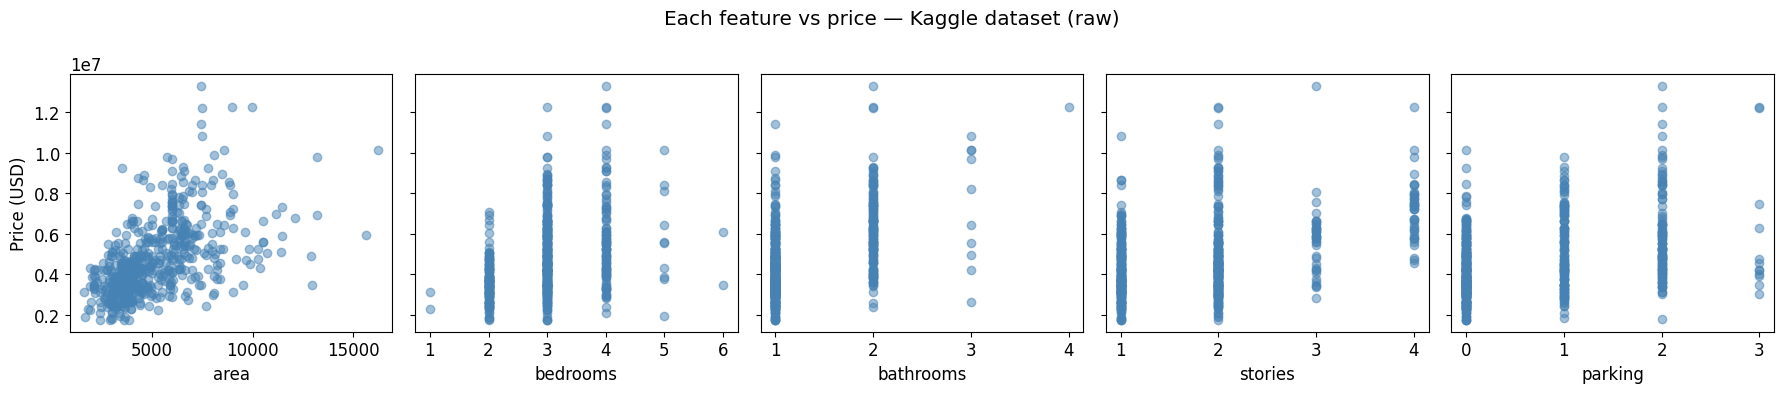

In [27]:
fig, ax = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, alpha=0.5, color='steelblue')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (USD)")
fig.suptitle("Each feature vs price — Kaggle dataset (raw)")
plt.tight_layout()
plt.show()

In [28]:
print("Peak to peak range — Raw features:")
for i, feat in enumerate(X_features):
    print(f"  {feat:12s}: {np.ptp(X_train[:,i]):.0f}")

Peak to peak range — Raw features:
  area        : 14550
  bedrooms    : 5
  bathrooms   : 3
  stories     : 3
  parking     : 3


In [29]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        f_wb = np.dot(X[i], w) + b
        cost += (f_wb - y[i]) ** 2
    total_cost = cost / (2 * m)
    return total_cost

In [30]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i, j]
        dj_db += err

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [31]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, compute_cost, compute_gradient):

    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i < 100000:
            cost = compute_cost(X, y, w, b)
            J_history.append(cost)
        
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:5d}: Cost {J_history[-1]:20,.2f}   ")
    return w, b, J_history

In [32]:
def zcore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [33]:
X_norm, X_mu, X_sigma = zcore_normalize_features(X_train)

print(f"X_mu    = {X_mu}")
print(f"X_sigma = {X_sigma}")
print(f"\nPeak to peak range — Normalized:")
for i, feat in enumerate(X_features):
    print(f"  {feat:12s}: {np.ptp(X_norm[:,i]):.4f}")

X_mu    = [5.15054128e+03 2.96513761e+00 1.28623853e+00 1.80550459e+00
 6.93577982e-01]
X_sigma = [2.16814915e+03 7.37386427e-01 5.02008423e-01 8.66696233e-01
 8.60794942e-01]

Peak to peak range — Normalized:
  area        : 6.7108
  bedrooms    : 6.7807
  bathrooms   : 5.9760
  stories     : 3.4614
  parking     : 3.4852


In [34]:
initial_w  = np.zeros(n)
initial_b  = 0.
alpha      = 1.0e-1
iterations = 1000

print("=" * 55)
print("  Gradient descent on NORMALIZED Kaggle features")
print("=" * 55)

w, b, J_hist = gradient_descent(X_norm, y_train, initial_w, initial_b,
                                alpha, iterations, compute_cost, compute_gradient)

print(f"\nw_final : {w}")
print(f"b_final : {b:,.2f}")

  Gradient descent on NORMALIZED Kaggle features
Iteration     0: Cost 10,627,336,936,292.21   


Iteration   100: Cost   765,504,491,417.85   
Iteration   200: Cost   765,504,281,335.34   
Iteration   300: Cost   765,504,281,334.20   
Iteration   400: Cost   765,504,281,334.20   
Iteration   500: Cost   765,504,281,334.20   
Iteration   600: Cost   765,504,281,334.20   
Iteration   700: Cost   765,504,281,334.20   
Iteration   800: Cost   765,504,281,334.20   
Iteration   900: Cost   765,504,281,334.20   

w_final : [717907.78079503 123740.66000951 569147.11127513 474897.36874447
 325032.97540215]
b_final : 4,766,729.25


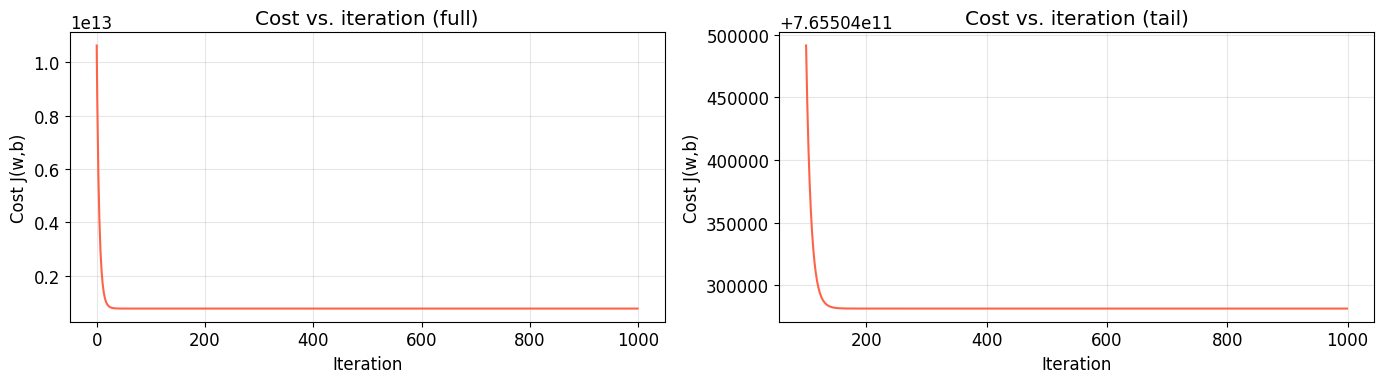

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(J_hist, color='tomato')
ax1.set_title("Cost vs. iteration (full)")
ax1.set_ylabel("Cost J(w,b)")
ax1.set_xlabel("Iteration")
ax1.grid(True, alpha=0.3)

ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:], color='tomato')
ax2.set_title("Cost vs. iteration (tail)")
ax2.set_ylabel("Cost J(w,b)")
ax2.set_xlabel("Iteration")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print("Predictions vs Actual — first 15 examples:")
print("-" * 65)
for i in range(15):
    pred = np.dot(X_norm[i], w) + b
    diff = abs(pred - y_train[i])
    pct  = (diff / y_train[i]) * 100
    print(f"  Pred: ${pred:>12,.0f}  |  Actual: ${y_train[i]:>12,.0f}  |  "
          f"Diff: ${diff:>9,.0f}  ({pct:.1f}%)")

Predictions vs Actual — first 15 examples:
-----------------------------------------------------------------
  Pred: $   7,648,874  |  Actual: $  13,300,000  |  Diff: $5,651,126  (42.5%)
  Pred: $  11,351,808  |  Actual: $  12,250,000  |  Diff: $  898,192  (7.3%)
  Pred: $   7,774,158  |  Actual: $  12,250,000  |  Diff: $4,475,842  (36.5%)
  Pred: $   7,505,020  |  Actual: $  12,215,000  |  Diff: $4,709,980  (38.6%)
  Pred: $   5,967,194  |  Actual: $  11,410,000  |  Diff: $5,442,806  (47.7%)
  Pred: $   7,545,414  |  Actual: $  10,850,000  |  Diff: $3,304,586  (30.5%)
  Pred: $   9,714,648  |  Actual: $  10,150,000  |  Diff: $  435,352  (4.3%)
  Pred: $  10,554,486  |  Actual: $  10,150,000  |  Diff: $  404,486  (4.0%)
  Pred: $   6,192,353  |  Actual: $   9,870,000  |  Diff: $3,677,647  (37.3%)
  Pred: $   7,098,445  |  Actual: $   9,800,000  |  Diff: $2,701,555  (27.6%)
  Pred: $   7,713,232  |  Actual: $   9,800,000  |  Diff: $2,086,768  (21.3%)
  Pred: $   7,764,490  |  Actual: $ 

In [40]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_norm, y_train)

print("=== Comparison: Gradient Descent vs Sklearn ===")
print(f"\n{'Feature':<12} {'Our w':>12} {'Sklearn w':>12} {'Diff':>12}")
print("-" * 52)
for i, feat in enumerate(X_features):
    diff = abs(w[i] - lr.coef_[i])
    print(f"{feat:<12} {w[i]:>12.2f} {lr.coef_[i]:>12.2f} {diff:>12.4f}")
print("-" * 52)
print(f"{'b':<12} {b:>12.2f} {lr.intercept_:>12.2f} "
      f"{abs(b - lr.intercept_):>12.4f}")

# Prediction at mean — mathematical property: should equal mean price
pred_at_mean = np.dot(np.zeros(n), w) + b  # normalized mean = zeros
print(f"\nPrediction at mean features : ${pred_at_mean:,.0f}")
print(f"Actual mean price           : ${y_train.mean():,.0f}")

=== Comparison: Gradient Descent vs Sklearn ===

Feature             Our w    Sklearn w         Diff
----------------------------------------------------
area            717907.78    717907.78       0.0000
bedrooms        123740.66    123740.66       0.0000
bathrooms       569147.11    569147.11       0.0000
stories         474897.37    474897.37       0.0000
parking         325032.98    325032.98       0.0000
----------------------------------------------------
b              4766729.25   4766729.25       0.0000

Prediction at mean features : $4,766,729
Actual mean price           : $4,766,729


In [42]:
# Predict a new house: 4000 sqft, 3 bed, 2 bath, 2 stories, 1 parking
x_new      = np.array([4000, 3, 2, 2, 1])
x_new_norm = (x_new - X_mu) / X_sigma      # same mu and sigma from training!

y_pred = np.dot(x_new_norm, w) + b

print("New house prediction:")
print(f"  area      : {x_new[0]:,} sqft")
print(f"  bedrooms  : {x_new[1]}")
print(f"  bathrooms : {x_new[2]}")
print(f"  stories   : {x_new[3]}")
print(f"  parking   : {x_new[4]}")
print(f"\n  Predicted price : ${y_pred:,.0f}")

New house prediction:
  area      : 4,000 sqft
  bedrooms  : 3
  bathrooms : 2
  stories   : 2
  parking   : 1

  Predicted price : $5,423,113
